In [ ]:
!pip install kaggle

In [ ]:
import os
from google.colab import files

kaggle_dir = '/root/.kaggle'
os.makedirs(kaggle_dir, exist_ok=True)

uploaded = files.upload()

for fn in uploaded.keys():
    !mv '{fn}' {kaggle_dir}/kaggle.json

!chmod 600 {kaggle_dir}/kaggle.json


In [ ]:
!mkdir -p /root/.kaggle

!chmod 600 /root/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d jessicali9530/celeba-dataset

Dataset URL: https://www.kaggle.com/datasets/jessicali9530/celeba-dataset
License(s): other
100% 1.33G/1.33G [00:07<00:00, 191MB/s]



In [ ]:
!unzip -q celeba-dataset.zip -d celeba

In [ ]:
!pip install facenet-pytorch mtcnn torchvision

In [ ]:
import torch
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

In [ ]:
transform = transforms.Compose([
    transforms.Resize(64),
    transforms.CenterCrop(64),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

dataset = ImageFolder(root='celeba/img_align_celeba', transform=transform)
dataloader = DataLoader(dataset, batch_size=128, shuffle=True, num_workers=2)

In [ ]:
import torch.nn as nn

Безусловная генерация

In [ ]:
nz = 100
nc = 3
ngf = 64
ndf = 64

class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.main = nn.Sequential(
            nn.ConvTranspose2d(nz, ngf * 8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf * 8),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf * 8, ngf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf * 2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf, nc, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, input):
        return self.main(input)

class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.main = nn.Sequential(

            nn.Conv2d(nc, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf * 4, ndf * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 8),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf * 8, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, input):
        return self.main(input).view(-1, 1).squeeze(1)

Условная генерация

In [ ]:
class ConditionalGenerator(nn.Module):
    def __init__(self, num_classes=2):
        super(ConditionalGenerator, self).__init__()
        self.label_emb = nn.Embedding(num_classes, num_classes)
        self.main = nn.Sequential(
            nn.ConvTranspose2d(nz + num_classes, ngf * 8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf * 8),
            nn.ReLU(True),
            nn.ConvTranspose2d(ngf * 8, ngf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True),
            nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),
            nn.ConvTranspose2d(ngf * 2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),
            nn.ConvTranspose2d(ngf, nc, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, noise, labels):
        c = self.label_emb(labels).unsqueeze(2).unsqueeze(3)
        x = torch.cat([noise, c], dim=1)
        return self.main(x)

class ConditionalDiscriminator(nn.Module):
    def __init__(self, num_classes=2):
        super(ConditionalDiscriminator, self).__init__()
        self.label_emb = nn.Embedding(num_classes, num_classes)
        self.main = nn.Sequential(
            nn.Conv2d(nc + num_classes, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf * 4, ndf * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 8),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf * 8, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, img, labels):
        c = self.label_emb(labels)
        c = c.view(c.size(0), c.size(1), 1, 1).expand(-1, -1, img.size(2), img.size(3))
        x = torch.cat([img, c], dim=1)
        return self.main(x).view(-1, 1).squeeze(1)

In [ ]:
import os
import pandas as pd
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import pandas as pd

Доступные атрибуты:

In [ ]:
csv_path = 'celeba/list_attr_celeba.csv'
print(pd.read_csv(csv_path, nrows=0))

Empty DataFrame
Columns: [image_id, 5_o_Clock_Shadow, Arched_Eyebrows, Attractive, Bags_Under_Eyes, Bald, Bangs, Big_Lips, Big_Nose, Black_Hair, Blond_Hair, Blurry, Brown_Hair, Bushy_Eyebrows, Chubby, Double_Chin, Eyeglasses, Goatee, Gray_Hair, Heavy_Makeup, High_Cheekbones, Male, Mouth_Slightly_Open, Mustache, Narrow_Eyes, No_Beard, Oval_Face, Pale_Skin, Pointy_Nose, Receding_Hairline, Rosy_Cheeks, Sideburns, Smiling, Straight_Hair, Wavy_Hair, Wearing_Earrings, Wearing_Hat, Wearing_Lipstick, Wearing_Necklace, Wearing_Necktie, Young]
Index: []

[0 rows x 41 columns]


In [ ]:
class CelebAConditionalDataset(Dataset):
    def __init__(self, csv_path, img_dir, transform=None, attribute_name='Male'):
        """
        csv_path: путь к файлу list_attr_celeba.csv
        img_dir: путь к папке с картинками img_align_celeba
        attribute_name: название колонки с атрибутом
        """
        self.df = pd.read_csv(csv_path)
        self.img_dir = img_dir
        self.transform = transform
        self.attr = attribute_name

        self.df[self.attr] = self.df[self.attr].replace(-1, 0)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name = self.df.iloc[idx]['image_id']
        img_path = os.path.join(self.img_dir, img_name)

        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        label = self.df.iloc[idx][self.attr]

        return image, label

In [ ]:
!ls celeba

img_align_celeba      list_bbox_celeba.csv     list_landmarks_align_celeba.csv
list_attr_celeba.csv  list_eval_partition.csv


In [ ]:
csv_path = 'celeba/list_attr_celeba.csv'
img_dir = 'celeba/img_align_celeba/img_align_celeba'

transform = transforms.Compose([
    transforms.Resize(64),
    transforms.CenterCrop(64),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

dataset = CelebAConditionalDataset(csv_path=csv_path, img_dir=img_dir, transform=transform)
dataloader = DataLoader(dataset, batch_size=128, shuffle=True, num_workers=2)

images, labels = next(iter(dataloader))
print("Размер батча картинок:", images.shape)
print("Размер батча меток:", labels.shape)
print("Примеры меток:", labels[:10].tolist())

Размер батча картинок: torch.Size([128, 3, 64, 64])
Размер батча меток: torch.Size([128])
Примеры меток: [1, 1, 0, 1, 0, 0, 0, 0, 0, 1]


In [ ]:
!pip install torchmetrics[image]

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.inception import InceptionScore
import matplotlib.pyplot as plt

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

netG = ConditionalGenerator(num_classes=2).to(device)
netD = ConditionalDiscriminator(num_classes=2).to(device)

criterion = nn.BCELoss()

optimizerD = optim.Adam(netD.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=0.0002, betas=(0.5, 0.999))

fid = FrechetInceptionDistance(feature=64).to(device)
inception = InceptionScore().to(device)

G_losses = []
D_losses = []

def to_uint8(img_tensor):
    img_tensor = (img_tensor + 1) / 2.0
    return (img_tensor * 255).to(torch.uint8)

num_epochs = 5
nz = 100

FIDs = []
ISs = []
epochs = 6
print("Начинаем обучение...")
for epoch in range(num_epochs):
    for i, data in enumerate(dataloader, 0):
        real_imgs, real_labels = data
        real_imgs = real_imgs.to(device)
        real_labels = real_labels.to(device)
        b_size = real_imgs.size(0)

        real_targets = torch.ones(b_size, device=device)
        fake_targets = torch.zeros(b_size, device=device)

        netD.zero_grad()

        output_real = netD(real_imgs, real_labels)
        errD_real = criterion(output_real, real_targets)
        errD_real.backward()

        noise = torch.randn(b_size, nz, 1, 1, device=device)
        fake_labels = torch.randint(0, 2, (b_size,), device=device)

        fake_imgs = netG(noise, fake_labels)

        output_fake = netD(fake_imgs.detach(), fake_labels)
        errD_fake = criterion(output_fake, fake_targets)
        errD_fake.backward()

        errD = errD_real + errD_fake
        optimizerD.step()

        netG.zero_grad()

        output_fake_for_G = netD(fake_imgs, fake_labels)
        errG = criterion(output_fake_for_G, real_targets)
        errG.backward()

        optimizerG.step()

        G_losses.append(errG.item())
        D_losses.append(errD.item())

        if i % 50 == 0:
            imgs_uint8_real = to_uint8(real_imgs)
            imgs_uint8_fake = to_uint8(fake_imgs)

            fid.update(imgs_uint8_real, real=True)
            fid.update(imgs_uint8_fake, real=False)
            inception.update(imgs_uint8_fake)

        if i % 100 == 0:
            print(f"[{epoch + 1}/{num_epochs}][{i}/{len(dataloader)}] "
                  f"Loss_D: {errD.item():.4f} Loss_G: {errG.item():.4f}")

    epoch_fid = fid.compute()
    epoch_is_mean, epoch_is_std = inception.compute()
    FIDs.append(epoch_fid.item())
    ISs.append(epoch_is_mean.item())
    fid.reset()
    inception.reset()

/usr/local/lib/python3.12/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: Metric `InceptionScore` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)


Начинаем обучение...
[1/5][0/1583] Loss_D: 1.2869 Loss_G: 2.5217
[1/5][100/1583] Loss_D: 0.8429 Loss_G: 3.4791
[1/5][200/1583] Loss_D: 0.8318 Loss_G: 1.0612
[1/5][300/1583] Loss_D: 1.6248 Loss_G: 1.5888
[1/5][400/1583] Loss_D: 1.4361 Loss_G: 1.4019
[1/5][500/1583] Loss_D: 0.8009 Loss_G: 1.1023
[1/5][600/1583] Loss_D: 0.4521 Loss_G: 1.6233
[1/5][700/1583] Loss_D: 0.5773 Loss_G: 2.3781
[1/5][800/1583] Loss_D: 0.9743 Loss_G: 1.1926
[1/5][900/1583] Loss_D: 0.1774 Loss_G: 3.1259
[1/5][1000/1583] Loss_D: 0.1345 Loss_G: 3.6066
[1/5][1100/1583] Loss_D: 0.5460 Loss_G: 0.9526
[1/5][1200/1583] Loss_D: 1.4719 Loss_G: 1.0885
[1/5][1300/1583] Loss_D: 0.7527 Loss_G: 2.2276
[1/5][1400/1583] Loss_D: 0.9308 Loss_G: 1.0693
[1/5][1500/1583] Loss_D: 1.7320 Loss_G: 1.4275
[2/5][0/1583] Loss_D: 0.6600 Loss_G: 2.7014
[2/5][100/1583] Loss_D: 0.1200 Loss_G: 2.5924
[2/5][200/1583] Loss_D: 0.2766 Loss_G: 2.0668
[2/5][300/1583] Loss_D: 1.3489 Loss_G: 0.5353
[2/5][400/1583] Loss_D: 2.3358 Loss_G: 2.3433
[2/5][500/1

In [ ]:
for i in range(0,5):
  print(f"epoch: {i+1} FID: {FIDs[i]:.2f}; IS: {ISs[i]:.2f}")

epoch: 1 FID: 28.29; IS: 3.64
epoch: 2 FID: 3.68; IS: 3.16
epoch: 3 FID: 2.57; IS: 2.90
epoch: 4 FID: 2.45; IS: 2.85
epoch: 5 FID: 2.20; IS: 2.74


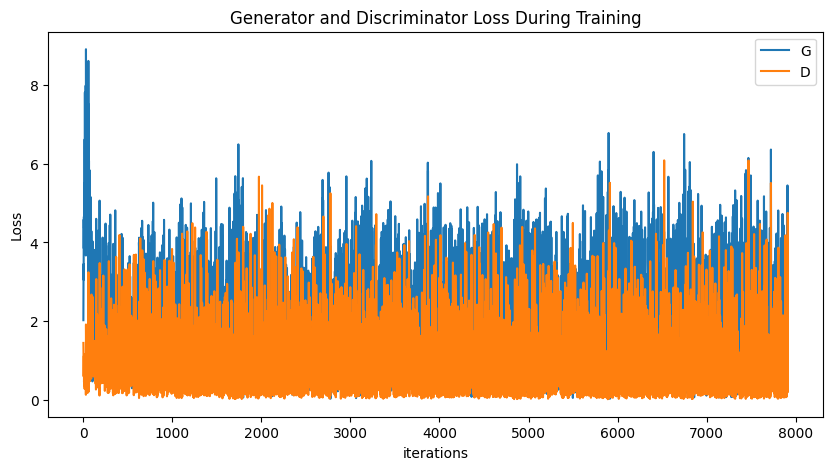

In [ ]:
plt.figure(figsize=(10,5))
plt.title("Generator and Discriminator Loss During Training")
plt.plot(G_losses, label="G")
plt.plot(D_losses, label="D")
plt.xlabel("iterations")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [ ]:
import torchvision.utils as vutils
import numpy as np

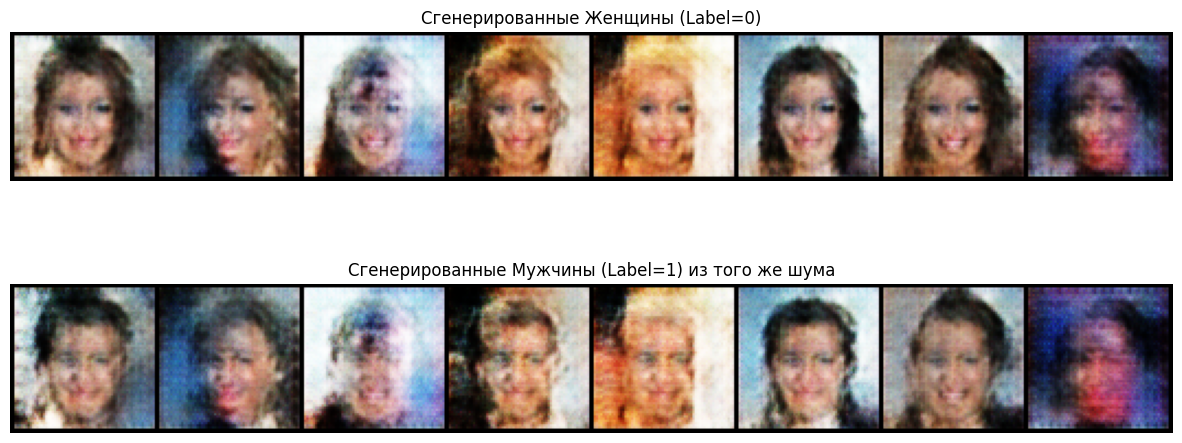

In [ ]:
fixed_noise = torch.randn(8, nz, 1, 1, device=device)

labels_women = torch.zeros(8, dtype=torch.long, device=device)
labels_men = torch.ones(8, dtype=torch.long, device=device)

netG.eval()
with torch.no_grad():
    fake_women = netG(fixed_noise, labels_women).detach().cpu()
    fake_men = netG(fixed_noise, labels_men).detach().cpu()

fig, ax = plt.subplots(2, 1, figsize=(15, 6))

ax[0].imshow(np.transpose(vutils.make_grid(fake_women, padding=2, normalize=True).numpy(), (1,2,0)))
ax[0].set_title("Сгенерированные Женщины (Label=0)")
ax[0].axis("off")

ax[1].imshow(np.transpose(vutils.make_grid(fake_men, padding=2, normalize=True).numpy(), (1,2,0)))
ax[1].set_title("Сгенерированные Мужчины (Label=1) из того же шума")
ax[1].axis("off")

plt.show()